In [2]:
import numpy as np,pandas as pd

In [3]:
df = pd.read_csv("../data/telco_customer_raw.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

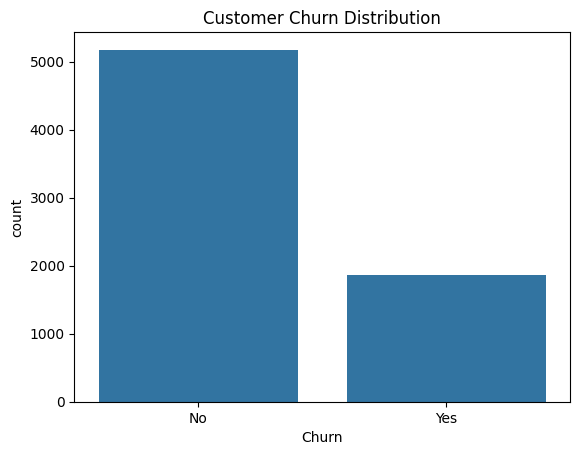

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

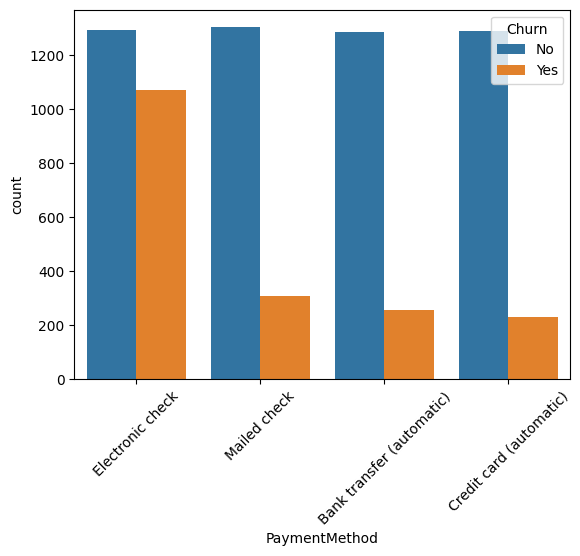

In [11]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=45)
plt.show()

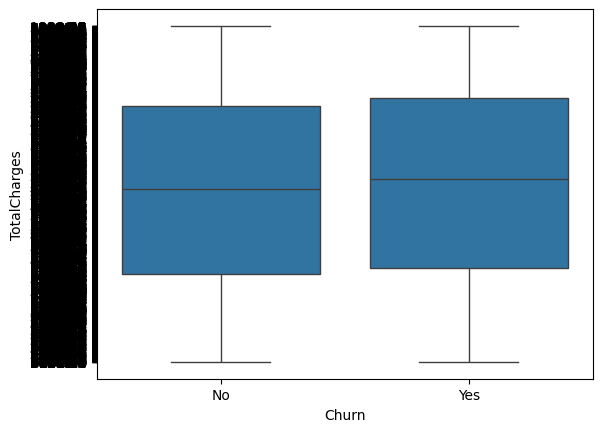

In [12]:
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.show()

In [13]:
for col in df.columns:
    print(col)

customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [14]:
for col in df.columns:
    if df[col].dtype in ["float64","int64"]:
        print(col)

SeniorCitizen
tenure
MonthlyCharges


In [15]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

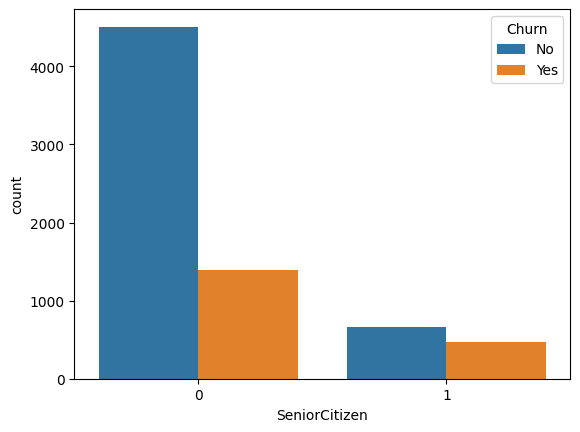

In [16]:
sns.countplot(data=df,x="SeniorCitizen",
              hue="Churn")
plt.show()

In [17]:
(df.groupby("SeniorCitizen")["Churn"]
 .value_counts(normalize=True).mul(100))

SeniorCitizen  Churn
0              No       76.393832
               Yes      23.606168
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

In [18]:
(df.groupby("gender")["Churn"].value_counts(normalize=True).mul(100))

gender  Churn
Female  No       73.079128
        Yes      26.920872
Male    No       73.839662
        Yes      26.160338
Name: proportion, dtype: float64

gender is not as much important feature as others

In [19]:
df["Partner"].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

<Axes: xlabel='Partner', ylabel='count'>

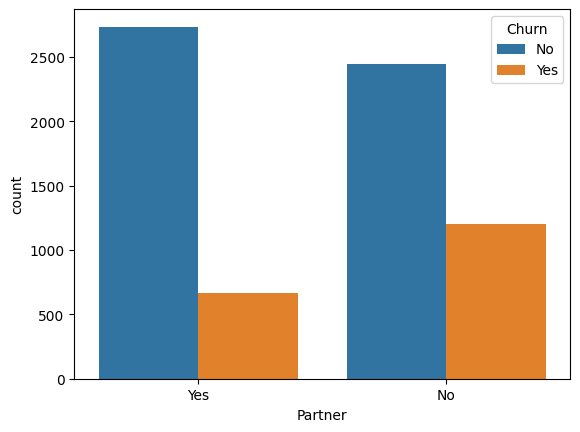

In [20]:
sns.countplot(data=df,x='Partner',hue='Churn')

In [21]:
(df.groupby("Partner")["Churn"].value_counts(normalize=True).mul(100))

Partner  Churn
No       No       67.042021
         Yes      32.957979
Yes      No       80.335097
         Yes      19.664903
Name: proportion, dtype: float64

In [22]:
(df.groupby("Dependents")["Churn"].value_counts(normalize=True).mul(100))

Dependents  Churn
No          No       68.720860
            Yes      31.279140
Yes         No       84.549763
            Yes      15.450237
Name: proportion, dtype: float64

<Axes: xlabel='tenure', ylabel='Churn'>

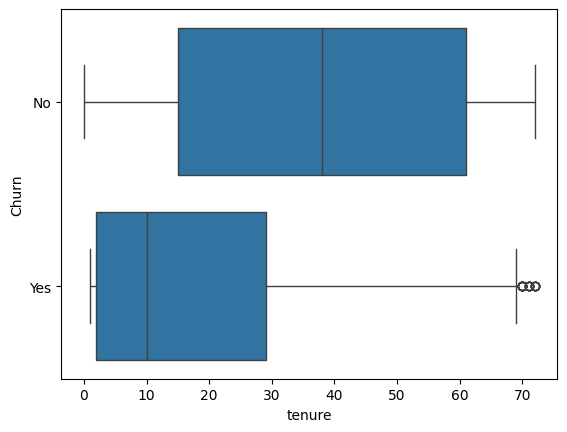

In [23]:
sns.boxplot(data=df,x="tenure",y="Churn")

PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn

In [24]:
df["PhoneService"].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

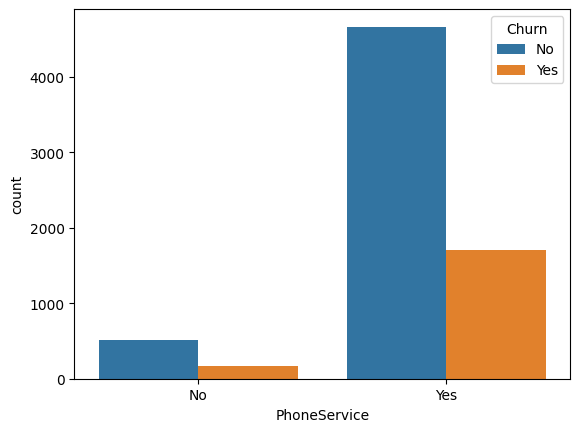

In [25]:
sns.countplot(data=df,x="PhoneService",hue="Churn")
plt.show()

In [26]:
(df.groupby("PhoneService")["Churn"].value_counts(normalize=True).mul(100))

PhoneService  Churn
No            No       75.073314
              Yes      24.926686
Yes           No       73.290363
              Yes      26.709637
Name: proportion, dtype: float64

In [27]:
(df.groupby("MultipleLines")["Churn"].value_counts(normalize=True).mul(100))

MultipleLines     Churn
No                No       74.955752
                  Yes      25.044248
No phone service  No       75.073314
                  Yes      24.926686
Yes               No       71.390104
                  Yes      28.609896
Name: proportion, dtype: float64

In [28]:
(df.groupby("InternetService")["Churn"].value_counts(normalize=True).mul(100))

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

In [29]:
(df.groupby("InternetService")["Churn"].value_counts(normalize=True).mul(100))

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

In [30]:
(df.groupby("OnlineSecurity")["Churn"].value_counts(normalize=True).mul(100))

OnlineSecurity       Churn
No                   No       58.233276
                     Yes      41.766724
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       85.388806
                     Yes      14.611194
Name: proportion, dtype: float64

In [31]:
(df.groupby("OnlineBackup")["Churn"].value_counts(normalize=True).mul(100))

OnlineBackup         Churn
No                   No       60.071244
                     Yes      39.928756
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       78.468506
                     Yes      21.531494
Name: proportion, dtype: float64

In [32]:
(df.groupby("TechSupport")["Churn"].value_counts(normalize=True).mul(100))

TechSupport          Churn
No                   No       58.364526
                     Yes      41.635474
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       84.833659
                     Yes      15.166341
Name: proportion, dtype: float64

In [33]:
(df.groupby("StreamingTV")["Churn"].value_counts(normalize=True).mul(100))

StreamingTV          Churn
No                   No       66.476868
                     Yes      33.523132
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       69.929812
                     Yes      30.070188
Name: proportion, dtype: float64

In [34]:
(df.groupby("StreamingMovies")["Churn"].value_counts(normalize=True).mul(100))

StreamingMovies      Churn
No                   No       66.319569
                     Yes      33.680431
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       70.058565
                     Yes      29.941435
Name: proportion, dtype: float64

In [35]:
(df.groupby("Contract")["Churn"].value_counts(normalize=True).mul(100))

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64

In [36]:
(df.groupby("PaperlessBilling")["Churn"].value_counts(normalize=True).mul(100))

PaperlessBilling  Churn
No                No       83.669916
                  Yes      16.330084
Yes               No       66.434908
                  Yes      33.565092
Name: proportion, dtype: float64

In [37]:
(df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).mul(100))

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64

In [38]:
(df.groupby("StreamingTV")["Churn"].value_counts(normalize=True).mul(100))

StreamingTV          Churn
No                   No       66.476868
                     Yes      33.523132
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       69.929812
                     Yes      30.070188
Name: proportion, dtype: float64

<Axes: xlabel='MonthlyCharges', ylabel='Churn'>

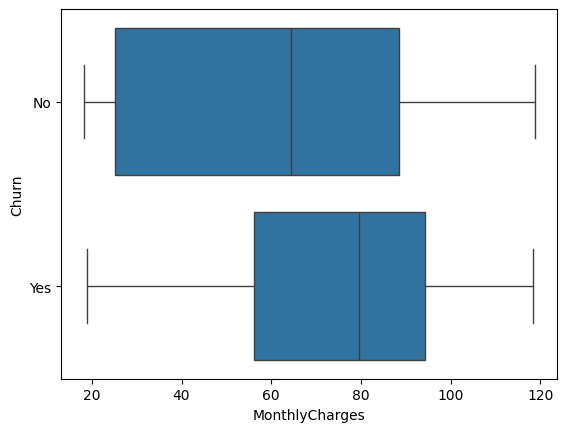

In [39]:
sns.boxplot(data=df,x="MonthlyCharges",y="Churn")

In [40]:
pd.cut(df["MonthlyCharges"], bins=[0, 30, 60, 90, 120])
pd.crosstab(
    pd.cut(df["MonthlyCharges"], bins=[0, 30, 60, 90, 120]),
    df["Churn"],
    normalize="index",
) * 100

Churn,No,Yes
MonthlyCharges,,
"(0, 30]",90.199637,9.800363
"(30, 60]",74.071146,25.928854
"(60, 90]",66.093881,33.906119
"(90, 120]",67.222542,32.777458


In [44]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [45]:
df["TotalCharges"].dtype

dtype('float64')

In [46]:
pd.crosstab(
    pd.cut(df["TotalCharges"], bins=[0, 500, 1500, 3000, 5000, 9000]),
    df["Churn"],
    normalize="index",
) * 100

Churn,No,Yes
TotalCharges,,
"(0, 500]",58.550000,41.450000
"(500, 1500]",75.195665,24.804335
"(1500, 3000]",76.178235,23.821765
"(3000, 5000]",81.945744,18.054256
"(5000, 9000]",86.167401,13.832599


# Key EDA Findings

1. The dataset is moderately imbalanced, with approximately 73% non-churned customers and 27% churned customers.

2. Tenure is one of the strongest indicators of churn. Customers with shorter tenure are significantly more likely to churn.

3. Customers without dependents exhibit a much higher churn rate than customers with dependents.

4. Senior citizens churn at a substantially higher rate than non-senior citizens.

5. Customers without Online Security or Tech Support services have significantly higher churn rates.

6. Month-to-month contract customers churn much more frequently than customers with one-year or two-year contracts.

7. MonthlyCharges are positively associated with churn. Customers paying higher monthly charges tend to churn more.

8. TotalCharges show an inverse relationship with churn because TotalCharges are strongly influenced by tenure. Long-term customers accumulate higher TotalCharges and are less likely to churn.

9. Gender does not appear to have a meaningful relationship with churn and is likely a weak predictor.

10. Contract type, tenure, OnlineSecurity, TechSupport, SeniorCitizen, Partner, and Dependents appear to be among the most informative features for predicting churn.
